In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image

ROOT = Path(r"D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV")

SPLITS = {
    "train": {
        "images": ROOT / "images" / "train",
        "labels": ROOT / "labels" / "train"
    },
    "val": {
        "images": ROOT / "images" / "val",
        "labels": ROOT / "labels" / "val"
    },
    "test": {
        "images": ROOT / "images" / "test",
        "labels": ROOT / "labels" / "test"
    }
}

print(ROOT)

D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV


In [2]:
def check_pairs(image_dir, label_dir):

    images = list(image_dir.glob("*.jpg"))
    labels = list(label_dir.glob("*.txt"))

    image_names = {p.stem for p in images}
    label_names = {p.stem for p in labels}

    missing_labels = sorted(image_names - label_names)
    missing_images = sorted(label_names - image_names)

    return {
        "images": len(images),
        "labels": len(labels),
        "missing_labels": missing_labels,
        "missing_images": missing_images
    }


for split, paths in SPLITS.items():

    result = check_pairs(
        paths["images"],
        paths["labels"]
    )

    print("\n", split.upper())
    print("Images:", result["images"])
    print("Labels:", result["labels"])
    print("Missing labels:", len(result["missing_labels"]))
    print("Missing images:", len(result["missing_images"]))

    if result["missing_labels"]:
        print(result["missing_labels"][:20])

    if result["missing_images"]:
        print(result["missing_images"][:20])


 TRAIN
Images: 5200
Labels: 5200
Missing labels: 0
Missing images: 0

 VAL
Images: 2600
Labels: 2600
Missing labels: 0
Missing images: 0

 TEST
Images: 2200
Labels: 2200
Missing labels: 0
Missing images: 0


In [3]:
def audit_labels(label_dir):

    errors = []
    empty = []
    total_objects = 0

    for label_path in sorted(label_dir.glob("*.txt")):

        content = label_path.read_text().strip()

        if not content:
            empty.append(label_path.stem)
            continue

        for line_number, line in enumerate(content.splitlines(), start=1):

            parts = line.split()

            if len(parts) != 5:

                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": "expected 5 values"
                })

                continue

            try:
                cls, xc, yc, w, h = map(float, parts)

            except ValueError:

                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": "non-numeric value"
                })

                continue

            total_objects += 1

            if cls != 0:

                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": f"unexpected class {cls}"
                })

            if not (0 <= xc <= 1):

                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": f"invalid xc={xc}"
                })

            if not (0 <= yc <= 1):

                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": f"invalid yc={yc}"
                })

            if not (0 < w <= 1):

                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": f"invalid width={w}"
                })

            if not (0 < h <= 1):

                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": f"invalid height={h}"
                })

    return total_objects, empty, errors

In [4]:
for split, paths in SPLITS.items():

    objects, empty, errors = audit_labels(
        paths["labels"]
    )

    print("\n", split.upper())

    print("UAV objects:", objects)
    print("Empty labels:", len(empty))
    print("Empty files:", empty)
    print("Errors:", len(errors))

    if errors:
        display(pd.DataFrame(errors).head(30))


 TRAIN
UAV objects: 5245
Empty labels: 1
Empty files: ['00639']
Errors: 0

 VAL
UAV objects: 2621
Empty labels: 0
Empty files: []
Errors: 1


,file,line,error
0,00991.txt,1,invalid height=0.0



 TEST
UAV objects: 2245
Empty labels: 0
Empty files: []
Errors: 0


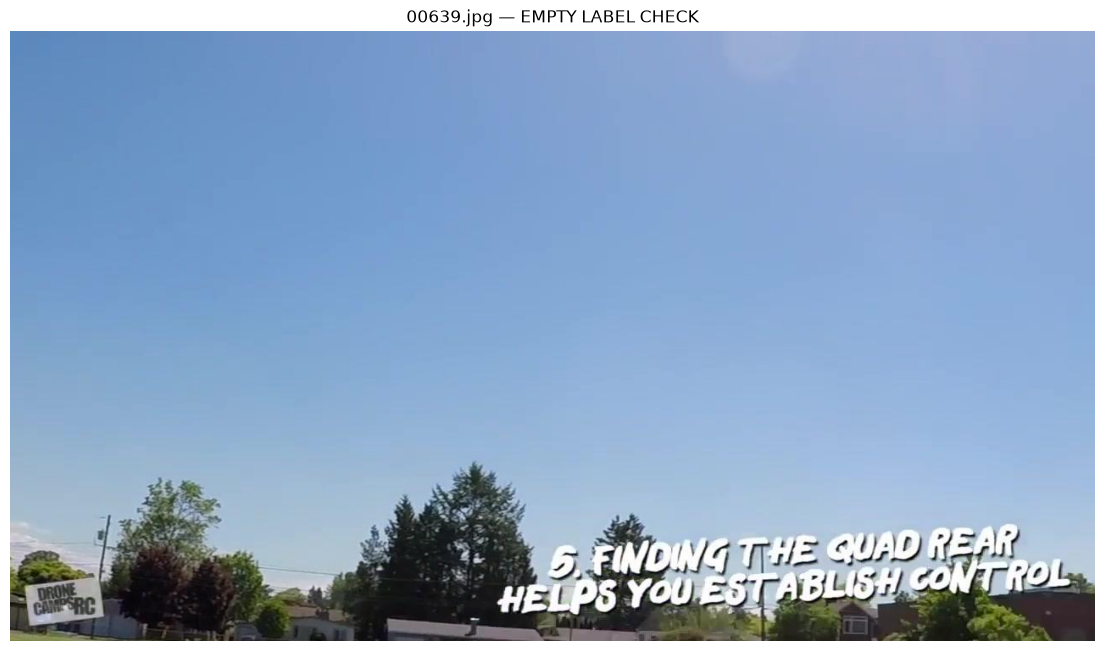

In [5]:
import matplotlib.pyplot as plt

image_path = SPLITS["train"]["images"] / "00639.jpg"

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(14, 8))
plt.imshow(image)
plt.title("00639.jpg — EMPTY LABEL CHECK")
plt.axis("off")
plt.show()

In [6]:
def check_bbox_boundaries(label_dir):

    problems = []

    for label_path in label_dir.glob("*.txt"):

        content = label_path.read_text().strip()

        if not content:
            continue

        for line_number, line in enumerate(content.splitlines(), 1):

            parts = line.split()

            if len(parts) != 5:
                continue

            cls, xc, yc, w, h = map(float, parts)

            x1 = xc - w / 2
            y1 = yc - h / 2

            x2 = xc + w / 2
            y2 = yc + h / 2

            if (
                x1 < 0 or
                y1 < 0 or
                x2 > 1 or
                y2 > 1
            ):

                problems.append({
                    "file": label_path.name,
                    "line": line_number,
                    "x1": x1,
                    "y1": y1,
                    "x2": x2,
                    "y2": y2
                })

    return problems

In [7]:
for split, paths in SPLITS.items():

    problems = check_bbox_boundaries(
        paths["labels"]
    )

    print(
        split,
        "boxes outside image:",
        len(problems)
    )

    if problems:
        display(pd.DataFrame(problems).head(20))

train boxes outside image: 16


,file,line,x1,y1,x2,y2
0,00155.txt,1,0.878126,0.830079,0.972656,1.001953
1,00470.txt,1,0.293749,0.509722,0.965624,1.001389
2,00505.txt,1,0.413281,0.708333,0.707031,1.001389
3,00526.txt,1,0.514844,0.804167,0.650000,1.001389
4,00605.txt,1,0.902343,0.693055,1.000781,0.822222
5,00606.txt,1,0.920313,0.866667,1.000781,0.966667
6,00827.txt,1,0.946353,0.256482,1.000520,0.314814
7,00841.txt,1,0.916667,0.245370,1.000521,0.308333
8,02708.txt,1,0.977603,0.565741,1.000520,0.590741
9,03333.txt,1,0.977083,0.263889,1.000521,0.295370


val boxes outside image: 7


,file,line,x1,y1,x2,y2
0,00022.txt,1,0.118000,0.123845,0.882000,1.001849
1,00299.txt,1,0.387501,0.001389,1.000781,0.309723
2,00304.txt,1,0.920313,0.866667,1.000781,0.968055
3,01852.txt,1,0.283333,0.996296,0.303646,1.000926
4,02391.txt,1,0.984375,0.375926,1.000521,0.391667
5,02460.txt,1,0.989063,0.577777,1.000521,0.592592
6,02499.txt,1,0.979687,0.612037,1.000520,0.632407


test boxes outside image: 10


,file,line,x1,y1,x2,y2
0,00078.txt,1,0.855468,0.519444,1.000781,0.637500
1,00230.txt,1,0.919531,0.868055,1.000781,0.970833
2,00231.txt,1,0.918751,0.865278,1.000781,0.966666
3,00456.txt,1,0.965625,0.413890,1.000521,0.446296
4,01095.txt,1,0.413281,0.181945,1.000001,0.776389
5,01174.txt,1,0.609375,0.831945,0.784375,1.001389
6,01227.txt,1,0.902343,0.694445,1.000781,0.823612
7,01228.txt,1,0.919531,0.865278,1.000781,0.970834
8,01312.txt,1,0.552345,0.001389,1.000781,0.466667
9,01561.txt,1,0.965625,0.413890,1.000521,0.446296


In [8]:
def check_corrupt_images(image_dir):

    bad_images = []

    for image_path in image_dir.glob("*.jpg"):

        try:

            with Image.open(image_path) as img:
                img.verify()

        except Exception as e:

            bad_images.append({
                "image": image_path.name,
                "error": str(e)
            })

    return bad_images

In [9]:
for split, paths in SPLITS.items():

    bad = check_corrupt_images(
        paths["images"]
    )

    print(
        split,
        "corrupt images:",
        len(bad)
    )

train corrupt images: 0
val corrupt images: 0
test corrupt images: 0


In [10]:
import hashlib


def file_md5(path, chunk_size=1024 * 1024):

    h = hashlib.md5()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()

In [11]:
split_hashes = {}

for split, paths in SPLITS.items():

    records = []

    for image_path in paths["images"].glob("*.jpg"):

        records.append({
            "file": image_path.name,
            "hash": file_md5(image_path)
        })

    split_hashes[split] = pd.DataFrame(records)

    print(
        split,
        len(split_hashes[split])
    )

train 5200
val 2600
test 2200


In [12]:
def find_overlap(split_a, split_b):

    a = split_hashes[split_a]
    b = split_hashes[split_b]

    overlap = a.merge(
        b,
        on="hash",
        suffixes=(
            f"_{split_a}",
            f"_{split_b}"
        )
    )

    return overlap

In [13]:
train_val_overlap = find_overlap(
    "train",
    "val"
)

train_test_overlap = find_overlap(
    "train",
    "test"
)

val_test_overlap = find_overlap(
    "val",
    "test"
)

print("Train ↔ Val:", len(train_val_overlap))
print("Train ↔ Test:", len(train_test_overlap))
print("Val ↔ Test:", len(val_test_overlap))

Train ↔ Val: 0
Train ↔ Test: 1
Val ↔ Test: 0


Image: 00579.jpg
Updated label content:
0 0.350781 0.275694 0.073438 0.079167


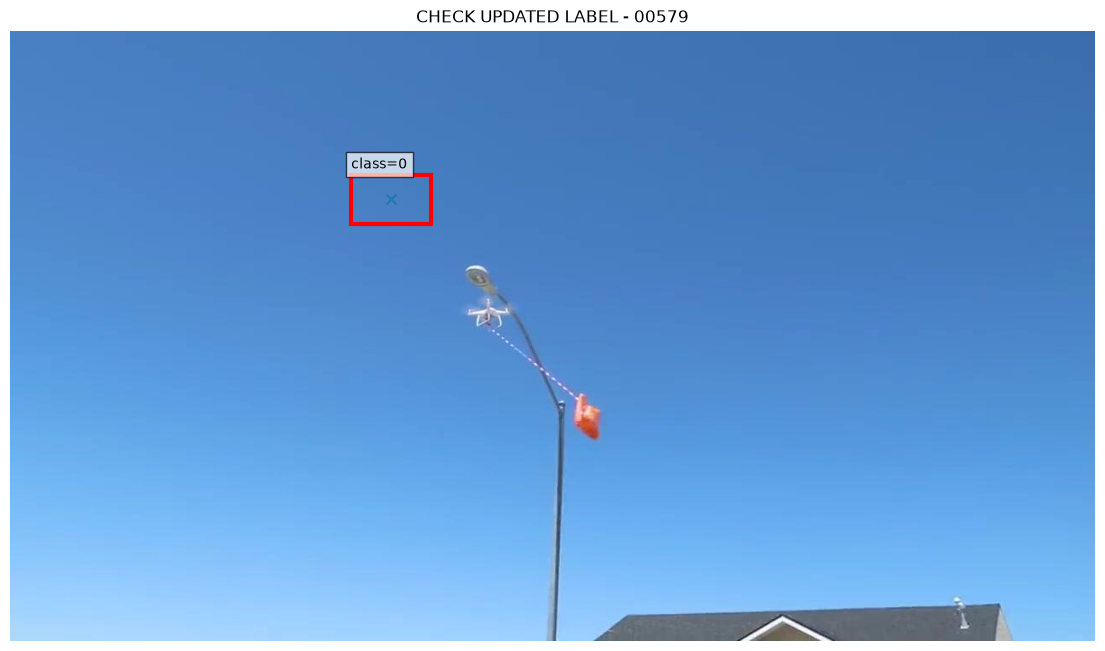

In [18]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# image you updated
image_name = "00579"

image_path = SPLITS["train"]["images"] / f"{image_name}.jpg"
label_path = SPLITS["train"]["labels"] / f"{image_name}.txt"

# load image
image = Image.open(image_path).convert("RGB")
W, H = image.size

print("Image:", image_path.name)
print("Updated label content:")
print(label_path.read_text())

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(image)

for line in label_path.read_text().splitlines():
    if not line.strip():
        continue

    cls, xc, yc, bw, bh = map(float, line.split())

    # YOLO normalized -> pixels
    xc_px = xc * W
    yc_px = yc * H
    bw_px = bw * W
    bh_px = bh * H

    x1 = xc_px - bw_px / 2
    y1 = yc_px - bh_px / 2

    rect = patches.Rectangle(
        (x1, y1),
        bw_px,
        bh_px,
        linewidth=3,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)

    # center point
    ax.scatter(xc_px, yc_px, s=50, marker="x")
    ax.text(
        x1,
        max(0, y1 - 8),
        f"class={int(cls)}",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7)
    )

ax.set_title(f"CHECK UPDATED LABEL - {image_name}")
ax.axis("off")
plt.show()

In [25]:
label_path = SPLITS["train"]["labels"]  / "00579.txt"

print("ACTUAL LABEL PATH:")
print(label_path.resolve())

print("\nCURRENT CONTENT:")
print(label_path.read_text())

ACTUAL LABEL PATH:
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\train\00579.txt

CURRENT CONTENT:
0 0.350781 0.275694 0.073438 0.079167


In [27]:
from ultralytics import YOLO

MODEL_PATH = r"\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\runs\04_experiments\EXP003_YOLOv8s_P2_960\weights\best.pt"

model = YOLO(MODEL_PATH)

In [28]:
image_path = SPLITS["train"]["images"]  / "00579.jpg"

results = model.predict(
    source=str(image_path),
    imgsz=960,
    conf=0.25,
    device=0,
    verbose=False
)

result = results[0]

print("Predictions:", len(result.boxes))

Predictions: 1


In [29]:
result.show()

In [31]:
boxes = result.boxes

best_idx = boxes.conf.argmax()

best_box = boxes.xywhn[best_idx].cpu().numpy()
best_conf = float(boxes.conf[best_idx])

xc, yc, w, h = best_box

print("Confidence:", best_conf)
print("New YOLO label:")
print(f"0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

Confidence: 0.2941726744174957
New YOLO label:
0 0.440292 0.462346 0.039960 0.067308


In [32]:
import shutil

label_path = SPLITS["train"]["labels"]  / "00579.txt"
backup_path = SPLITS["train"]["labels"]  / "00579_backup_old.txt"

# Backup القديم
shutil.copy2(label_path, backup_path)

# كتابة الـlabel الجديد
new_label = f"0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n"

label_path.write_text(new_label)

print("UPDATED:")
print(label_path.resolve())

print("\nNew content:")
print(label_path.read_text())

UPDATED:
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\train\00579.txt

New content:
0 0.440292 0.462346 0.039960 0.067308



Image: D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\train\00579.jpg
Label: D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\train\00579.txt
Current label content:
0 0.440292 0.462346 0.039960 0.067308



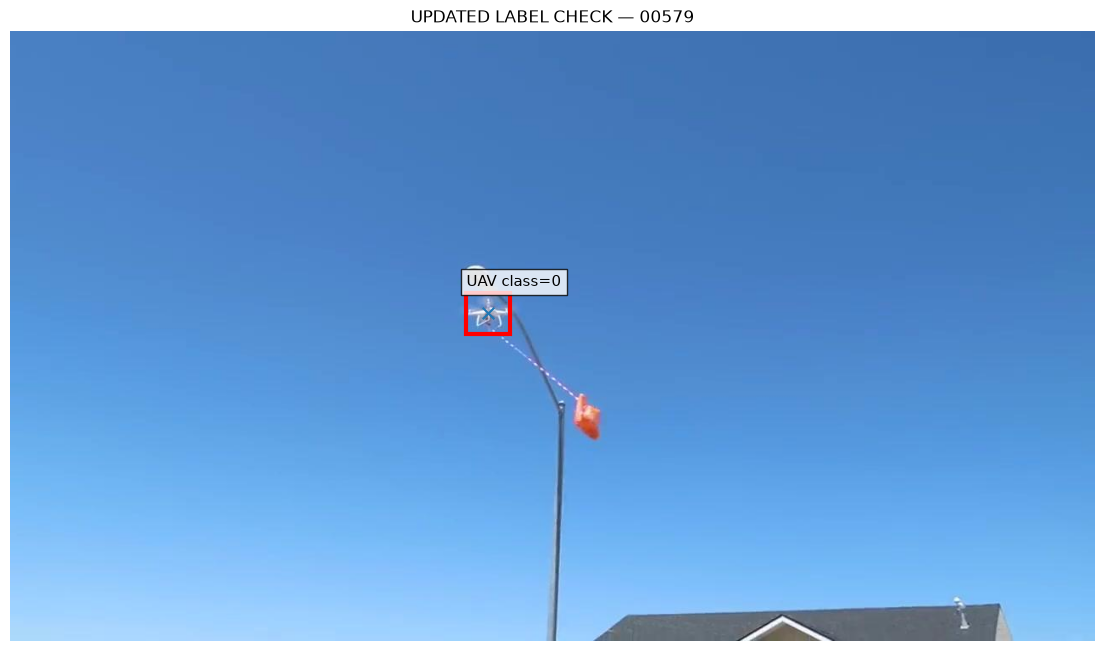

In [33]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

image_name = "00579"

image_path = SPLITS["train"]["images"]  / f"{image_name}.jpg"
label_path = SPLITS["train"]["labels"]  / f"{image_name}.txt"

# Load image
image = Image.open(image_path).convert("RGB")
W, H = image.size

print("Image:", image_path)
print("Label:", label_path)
print("Current label content:")
print(label_path.read_text())

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(image)

for line in label_path.read_text().splitlines():

    if not line.strip():
        continue

    cls, xc, yc, bw, bh = map(float, line.split())

    # YOLO normalized -> pixels
    xc_px = xc * W
    yc_px = yc * H
    bw_px = bw * W
    bh_px = bh * H

    x1 = xc_px - bw_px / 2
    y1 = yc_px - bh_px / 2

    rect = patches.Rectangle(
        (x1, y1),
        bw_px,
        bh_px,
        linewidth=3,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)

    ax.scatter(
        xc_px,
        yc_px,
        marker="x",
        s=70
    )

    ax.text(
        x1,
        max(0, y1 - 8),
        f"UAV class={int(cls)}",
        fontsize=11,
        bbox=dict(
            facecolor="white",
            alpha=0.8
        )
    )

ax.set_title(f"UPDATED LABEL CHECK — {image_name}")
ax.axis("off")

plt.show()

In [19]:
row = train_test_overlap.iloc[0]

train_file = row["file_train"]
test_file  = row["file_test"]

print("Train duplicate:", train_file)
print("Test duplicate :", test_file)

Train duplicate: 00259.jpg
Test duplicate : 01374.jpg


In [20]:
train_image_path = SPLITS["train"]["images"] / train_file
train_label_path = SPLITS["train"]["labels"] / f"{Path(train_file).stem}.txt"

print("Will remove:")
print(train_image_path)
print(train_label_path)

Will remove:
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\images\train\00259.jpg
D:\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\labels\train\00259.txt


In [21]:
train_image_path.unlink()
train_label_path.unlink()

print("Removed duplicate from TRAIN.")

Removed duplicate from TRAIN.


In [22]:
train_val_overlap = find_overlap("train", "val")
train_test_overlap = find_overlap("train", "test")
val_test_overlap = find_overlap("val", "test")

print("Train ↔ Val:", len(train_val_overlap))
print("Train ↔ Test:", len(train_test_overlap))
print("Val ↔ Test:", len(val_test_overlap))

Train ↔ Val: 0
Train ↔ Test: 1
Val ↔ Test: 0


In [23]:
import hashlib
import pandas as pd

def file_md5(path, chunk_size=1024 * 1024):
    h = hashlib.md5()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# REBUILD hashes from CURRENT files on disk
split_hashes = {}

for split, paths in SPLITS.items():

    records = []

    for image_path in paths["images"].glob("*.jpg"):

        records.append({
            "file": image_path.name,
            "hash": file_md5(image_path)
        })

    split_hashes[split] = pd.DataFrame(records)

    print(
        split,
        "images currently on disk:",
        len(split_hashes[split])
    )

train images currently on disk: 5199
val images currently on disk: 2600
test images currently on disk: 2200


In [24]:
train_val_overlap = find_overlap("train", "val")
train_test_overlap = find_overlap("train", "test")
val_test_overlap = find_overlap("val", "test")

print("Train ↔ Val:", len(train_val_overlap))
print("Train ↔ Test:", len(train_test_overlap))
print("Val ↔ Test:", len(val_test_overlap))

Train ↔ Val: 0
Train ↔ Test: 0
Val ↔ Test: 0


Label content:
''


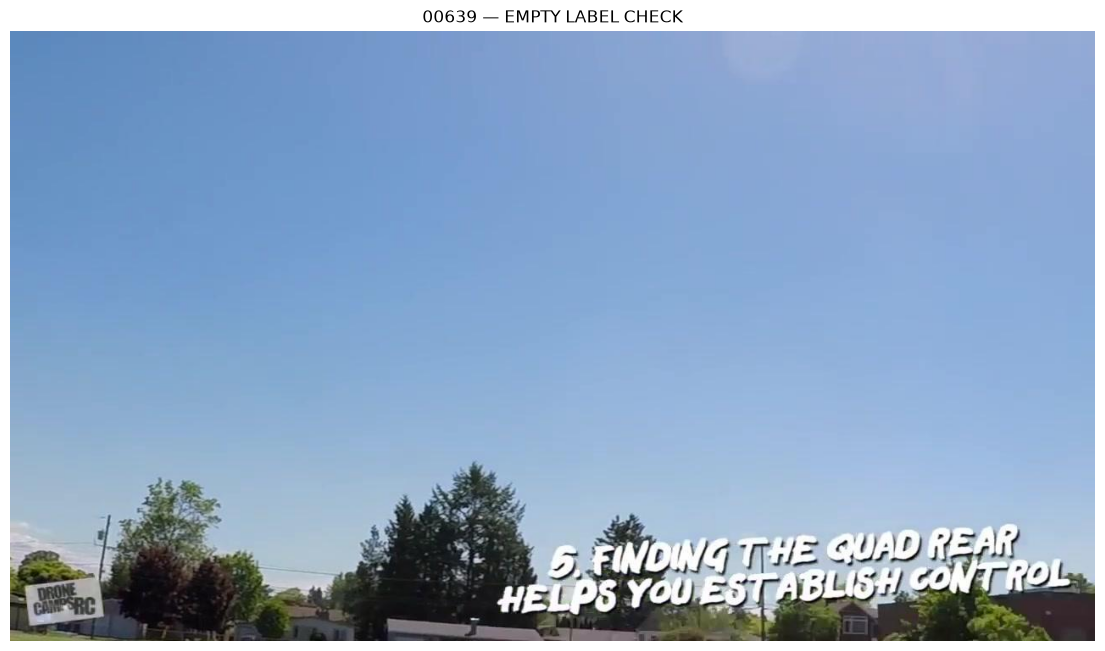

In [34]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = SPLITS["train"]["images"] / "00639.jpg"
label_path = SPLITS["train"]["labels"] / "00639.txt"

print("Label content:")
print(repr(label_path.read_text()))

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(14, 8))
plt.imshow(image)
plt.title("00639 — EMPTY LABEL CHECK")
plt.axis("off")
plt.show()

In [35]:
def audit_labels(label_dir):

    errors = []
    empty = []
    total_objects = 0

    for label_path in sorted(label_dir.glob("*.txt")):

        content = label_path.read_text().strip()

        if not content:
            empty.append(label_path.stem)
            continue

        for line_number, line in enumerate(content.splitlines(), start=1):

            parts = line.split()

            if len(parts) != 5:
                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": "expected 5 values"
                })
                continue

            try:
                cls, xc, yc, w, h = map(float, parts)

            except ValueError:
                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": "non-numeric value"
                })
                continue

            total_objects += 1

            if cls != 0:
                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": f"unexpected class {cls}"
                })

            if not (0 <= xc <= 1):
                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": f"invalid xc={xc}"
                })

            if not (0 <= yc <= 1):
                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": f"invalid yc={yc}"
                })

            if not (0 < w <= 1):
                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": f"invalid width={w}"
                })

            if not (0 < h <= 1):
                errors.append({
                    "file": label_path.name,
                    "line": line_number,
                    "error": f"invalid height={h}"
                })

    return total_objects, empty, errors

In [36]:
audit_results = {}

for split, paths in SPLITS.items():

    objects, empty, errors = audit_labels(
        paths["labels"]
    )

    audit_results[split] = {
        "objects": objects,
        "empty": empty,
        "errors": errors
    }

    print("\n======================")
    print(split.upper())
    print("======================")

    print("Objects:", objects)
    print("Empty labels:", len(empty))
    print("Empty files:", empty)
    print("Label errors:", len(errors))


TRAIN
Objects: 5245
Empty labels: 1
Empty files: ['00639']
Label errors: 0

VAL
Objects: 2621
Empty labels: 0
Empty files: []
Label errors: 1

TEST
Objects: 2245
Empty labels: 0
Empty files: []
Label errors: 0


In [37]:
def check_bbox_boundaries(label_dir):

    problems = []

    for label_path in sorted(label_dir.glob("*.txt")):

        content = label_path.read_text().strip()

        if not content:
            continue

        for line_number, line in enumerate(content.splitlines(), start=1):

            parts = line.split()

            if len(parts) != 5:
                continue

            cls, xc, yc, w, h = map(float, parts)

            x1 = xc - w / 2
            y1 = yc - h / 2
            x2 = xc + w / 2
            y2 = yc + h / 2

            if (
                x1 < 0 or
                y1 < 0 or
                x2 > 1 or
                y2 > 1
            ):

                problems.append({
                    "file": label_path.name,
                    "line": line_number,
                    "x1": x1,
                    "y1": y1,
                    "x2": x2,
                    "y2": y2
                })

    return problems


for split, paths in SPLITS.items():

    problems = check_bbox_boundaries(
        paths["labels"]
    )

    print(
        split,
        "boxes outside image:",
        len(problems)
    )

    if problems:
        display(pd.DataFrame(problems).head(20))

train boxes outside image: 16


,file,line,x1,y1,x2,y2
0,00155.txt,1,0.878126,0.830079,0.972656,1.001953
1,00470.txt,1,0.293749,0.509722,0.965624,1.001389
2,00505.txt,1,0.413281,0.708333,0.707031,1.001389
3,00526.txt,1,0.514844,0.804167,0.650000,1.001389
4,00605.txt,1,0.902343,0.693055,1.000781,0.822222
5,00606.txt,1,0.920313,0.866667,1.000781,0.966667
6,00827.txt,1,0.946353,0.256482,1.000520,0.314814
7,00841.txt,1,0.916667,0.245370,1.000521,0.308333
8,02708.txt,1,0.977603,0.565741,1.000520,0.590741
9,03333.txt,1,0.977083,0.263889,1.000521,0.295370


val boxes outside image: 7


,file,line,x1,y1,x2,y2
0,00022.txt,1,0.118000,0.123845,0.882000,1.001849
1,00299.txt,1,0.387501,0.001389,1.000781,0.309723
2,00304.txt,1,0.920313,0.866667,1.000781,0.968055
3,01852.txt,1,0.283333,0.996296,0.303646,1.000926
4,02391.txt,1,0.984375,0.375926,1.000521,0.391667
5,02460.txt,1,0.989063,0.577777,1.000521,0.592592
6,02499.txt,1,0.979687,0.612037,1.000520,0.632407


test boxes outside image: 10


,file,line,x1,y1,x2,y2
0,00078.txt,1,0.855468,0.519444,1.000781,0.637500
1,00230.txt,1,0.919531,0.868055,1.000781,0.970833
2,00231.txt,1,0.918751,0.865278,1.000781,0.966666
3,00456.txt,1,0.965625,0.413890,1.000521,0.446296
4,01095.txt,1,0.413281,0.181945,1.000001,0.776389
5,01174.txt,1,0.609375,0.831945,0.784375,1.001389
6,01227.txt,1,0.902343,0.694445,1.000781,0.823612
7,01228.txt,1,0.919531,0.865278,1.000781,0.970834
8,01312.txt,1,0.552345,0.001389,1.000781,0.466667
9,01561.txt,1,0.965625,0.413890,1.000521,0.446296
